# Gaußpuls-Optimierung

Dieses Notebook implementiert eine vereinfachte Version der Pulsoptimierung für einen Gaußpuls in der Sequenzdatei "50.seq". Im Gegensatz zur ursprünglichen `training.py` optimieren wir hier direkt das Signal zu Beginn des ADC-Events (`n_backlog=0`) anstelle einer Signaldifferenz.

## Importieren der erforderlichen Bibliotheken

In [1]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from bmc.fid.engine import BMCSim
# Importiere den neuen SingleSimBMCWrapper statt des DifferentiableBMCSimWrapper
from bmc.optimize.gauss_optimization.single_sim_optimizer import SingleSimBMCWrapper
from bmc.bmc_tool import prep_rf_simulation, prep_grad_simulation
from bmc.set_params import load_params
from bmc.utils.global_device import GLOBAL_DEVICE

# Aktiviere interaktive Plots

## Hilfsfunktionen definieren

In [2]:
def signal_objective_function(signal, rf_parameters=None, edge_penalty_weight=0.0, smoothness_weight=0.0):
    """
    Berechnet den Zielwert für die Optimierung des Signals.
    Wir maximieren das Signal, also ist das Ziel, den negativen Signalwert zu minimieren.
    Mit optionaler Strafe für Nicht-Null-Werte an den Enden des Pulses.
    
    Args:
        signal: Signal-Tensor
        rf_parameters: Liste der RF-Parameter [amp, phase] (optional)
        edge_penalty_weight: Gewichtung für die Strafe auf Nicht-Null-Enden (0.0 = deaktiviert)
        smoothness_weight: Gewichtung für die Glättung der Pulsform (0.0 = deaktiviert)
        
    Returns:
        Verlust: Negatives Signal (+ ggf. Strafen)
    """
    # Bei der Optimierung wollen wir den Betrag des Signals maximieren
    signal_loss = -torch.abs(signal)
    
    total_penalty = 0.0
    
    # Wenn rf_parameters übergeben wurden, Strafen anwenden
    if rf_parameters is not None:
        # Strafe für Nicht-Null-Enden
        if edge_penalty_weight > 0:
            edge_penalty = 0.0
            for amp, _ in rf_parameters:
                # Berechne Strafe für die ersten und letzten N Samples
                n_samples = 10  # Anzahl der Samples am Anfang und Ende, die nahe bei 0 sein sollen
                first_samples = amp[:n_samples]  # Erste N Samples
                last_samples = amp[-n_samples:]  # Letzte N Samples
                
                # Strafe berechnen (quadratisch, um größere Abweichungen stärker zu bestrafen)
                edge_penalty += torch.sum(first_samples**2) + torch.sum(last_samples**2)
            
            total_penalty += edge_penalty_weight * edge_penalty
        
        # Strafe für nicht-glatte Übergänge
        if smoothness_weight > 0:
            smoothness_penalty = 0.0
            for amp, _ in rf_parameters:
                # Berechne die Differenzen zwischen aufeinanderfolgenden Samples
                diffs = amp[1:] - amp[:-1]
                
                # Bestrafe große Unterschiede (quadratisch)
                smoothness_penalty += torch.sum(diffs**2)
            
            total_penalty += smoothness_weight * smoothness_penalty
    
    return signal_loss + total_penalty

def save_checkpoint(checkpoint_dir, rf_parameters, optimizer, epoch, loss, signal, 
                  checkpoint_name=None):
    """
    Speichert einen Checkpoint mit allen relevanten Trainingsparametern.
    """
    if checkpoint_name is None:
        checkpoint_name = f"checkpoint_epoch_{epoch}.pt"
    
    # Erstelle Checkpoint-Verzeichnis, falls es nicht existiert
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    # Bereite RF-Parameter für die Speicherung vor
    rf_param_state = []
    for amp, phase in rf_parameters:
        rf_param_state.append([amp.detach().clone(), phase.detach().clone()])
    
    # Erstelle Checkpoint-Dictionary
    checkpoint = {
        'epoch': epoch,
        'rf_parameters': rf_param_state,
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'signal': signal
    }
    
    # Speichere Checkpoint
    checkpoint_path = os.path.join(checkpoint_dir, checkpoint_name)
    torch.save(checkpoint, checkpoint_path)
    
    # Speichere zusätzliche Metadaten
    metadata = {
        'timestamp': datetime.now().isoformat(),
        'epoch': epoch,
        'loss': float(loss),
        'signal': float(signal)
    }
    metadata_path = os.path.join(checkpoint_dir, 'gauss_training_metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    
    return checkpoint_path

def load_checkpoint(checkpoint_path, optimizer=None):
    """
    Lädt einen Checkpoint und stellt den Trainingszustand wieder her.
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint-Datei {checkpoint_path} wurde nicht gefunden.")
    
    checkpoint = torch.load(checkpoint_path)
    
    # RF-Parameter laden
    rf_parameters = checkpoint['rf_parameters']
    
    # Optimierer-Zustand laden, falls vorhanden
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    return rf_parameters, checkpoint['epoch'], checkpoint['loss'], checkpoint['signal']

def plot_progress(epochs, losses, signals, save_path=None):
    """
    Plottet den Fortschritt des Trainings.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Plot für Verlust
    ax1.plot(epochs, losses, 'b-', marker='o')
    ax1.set_ylabel('Verlust')
    ax1.set_title('Trainingsverlauf')
    ax1.grid(True)
    
    # Plot für Signal
    ax2.plot(epochs, signals, 'r-', marker='o')
    ax2.set_xlabel('Epoche')
    ax2.set_ylabel('Signal')
    ax2.grid(True)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    return fig

## Initialisierung der Parameter und Simulationsumgebung

Wir verwenden die Sequenzdatei "50.seq" für unsere Optimierung. Diese enthält bereits einen Gaußpuls mit einem Flipwinkel von 50°.

In [3]:
def get_params():
    """
    Initialisiert die Parameter für das Training.
    """
    base_dir = Path().resolve().parent.parent.parent
    config_file = base_dir / "sim_lib" / "config_1pool.yaml"
    seq_file = base_dir / "seq_lib" / "50.seq"  # Hier verwenden wir die 50.seq Datei

    if not Path(config_file).exists():
        raise FileNotFoundError(f"Konfigurationsdatei {config_file} nicht gefunden.")

    if not Path(seq_file).exists():
        raise FileNotFoundError(f"Sequenzdatei {seq_file} nicht gefunden.")
    
    print(f"Verwende Sequenzdatei: {seq_file}")
    print(f"Verwende Konfigurationsdatei: {config_file}")
    
    sim_params = load_params(config_file)

    # Erstelle Positionen für die Simulation
    low = -1e-3
    high = 1e-3
    n_iso = 100
    z_pos = np.linspace(low, high, n_iso)
    z_pos = torch.tensor(z_pos)
    z_pos = torch.cat((z_pos, torch.tensor([0.0]))) 
    
    print(f"Anzahl der Isochromaten: {len(z_pos)}")

    # Initialisiere Simulationsengine mit n_backlog=0 für Signal am Beginn des ADC
    sim_engine_instance = BMCSim(adc_time=5e-3,
                                params=sim_params,
                                seq_file=seq_file,
                                z_positions=z_pos,
                                n_backlog=0,  # Wichtig: Signal am Beginn des ADC
                                verbose=True,
                                webhook=False)
    
    # Verwende den neuen SingleSimBMCWrapper
    diff_sim = SingleSimBMCWrapper(sim_engine_instance)
    
    # Extrahiere RF-Parameter aus der Sequenz
    rf_parameters = []  # Liste für [amp, phase] Paare
    dtp_rf = None
    
    for i, block_event in enumerate(diff_sim.sim_engine.seq.block_events, start=1):
        block = sim_engine_instance.seq.get_block(block_event)
        if block.rf:
            if hasattr(block, "block_duration") and block.block_duration != "0":
                amp_, ph_, dtp_rf, delay_after_pulse = prep_rf_simulation(
                    block, sim_engine_instance.params.options["max_pulse_samples"])
                print(f"RF-Block {i}: Form mit {len(amp_)} Samples, dtp_rf: {dtp_rf}")
                
                # Konstante Phase von 0 für alle Samples
                ph_ = torch.zeros_like(amp_)
                
                # Aktiviere Gradienten für Amplituden
                amp_.requires_grad_(True)
                
                # Füge das [amp, phase] Paar zur Liste hinzu
                rf_parameters.append([amp_, ph_])

    if not rf_parameters:
        raise ValueError("Keine RF-Blöcke in der Sequenz gefunden.")
    
    print(f"Anzahl der RF-Pulse: {len(rf_parameters)}")
    print(f"RF-Puls 1 Amplitude Form: {rf_parameters[0][0].shape}")
    print(f"RF-Puls 1 Phase Form: {rf_parameters[0][1].shape}")
    
    return rf_parameters, sim_params, seq_file, z_pos, diff_sim, dtp_rf

# Parameter holen
rf_parameters, sim_params, seq_file, z_pos, diff_sim, dtp_rf = get_params()

Verwende Sequenzdatei: /Users/danielmiksch/JupyterLab/optim/seq_lib/50.seq
Verwende Konfigurationsdatei: /Users/danielmiksch/JupyterLab/optim/sim_lib/config_1pool.yaml
Anzahl der Isochromaten: 101
RF-Block 2: Form mit 286 Samples, dtp_rf: 7.000000000000001e-06
Anzahl der RF-Pulse: 1
RF-Puls 1 Amplitude Form: torch.Size([286])
RF-Puls 1 Phase Form: torch.Size([286])


## Visualisierung des ursprünglichen Gaußpulses

Bevor wir mit der Optimierung beginnen, wollen wir uns die aktuelle Form des RF-Pulses ansehen.

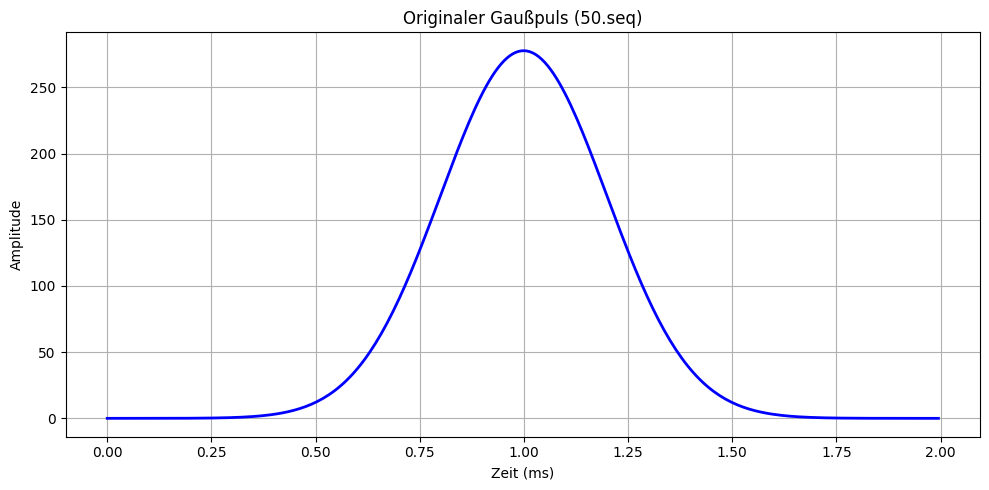

In [4]:
def visualize_pulse(parameters, dtp, title="RF-Puls"):
    """
    Visualisiert einen RF-Puls.
    """
    # Nehmen wir an, dass der RF-Puls im ersten Block ist
    # Extrahiere nur die Amplituden aus den Parametern (erstes Element des ersten Pulses)
    pulse = parameters[0][0].detach().cpu().numpy()
    time_axis = np.arange(len(pulse)) * dtp * 1000  # Umrechnung in ms
    
    plt.figure(figsize=(10, 5))
    plt.plot(time_axis, pulse, 'b-', linewidth=2)
    plt.title(title)
    plt.xlabel('Zeit (ms)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()
    # return plt.gcf()

# Original-Puls visualisieren
visualize_pulse(rf_parameters, dtp_rf, "Originaler Gaußpuls (50.seq)")

## Simulieren des ursprünglichen Signals

Bevor wir mit der Optimierung beginnen, wollen wir das aktuelle Signal messen.

In [5]:
with torch.no_grad():
    # RF-Parameter direkt an diff_sim übergeben
    original_signal = diff_sim(rf_parameters)

print(f"Signal des Original-Pulses: {original_signal.item():.6f}")

# Den ursprünglichen Puls für späteren Vergleich speichern
original_pulse_parameters = []
for amp, phase in rf_parameters:
    original_pulse_parameters.append([amp.detach().clone(), phase.detach().clone()])

Signal des Original-Pulses: 0.755150


## Training des RF-Pulses

Jetzt führen wir das Training durch, um den RF-Puls zu optimieren.

Epoche 0/199 - Signal: 0.755150, Verlust: -0.275282, LR: 1.000000
  Neuer Bestwert gefunden und gespeichert!
Epoche 1/199 - Signal: 0.760418, Verlust: -0.268091, LR: 0.998000
  Neuer Bestwert gefunden und gespeichert!
Epoche 1/199 - Signal: 0.760418, Verlust: -0.268091, LR: 0.998000
  Neuer Bestwert gefunden und gespeichert!
Epoche 2/199 - Signal: 0.764673, Verlust: -0.298051, LR: 0.996004
  Neuer Bestwert gefunden und gespeichert!
Epoche 2/199 - Signal: 0.764673, Verlust: -0.298051, LR: 0.996004
  Neuer Bestwert gefunden und gespeichert!
Epoche 3/199 - Signal: 0.768820, Verlust: -0.307392, LR: 0.994012
  Neuer Bestwert gefunden und gespeichert!
Epoche 3/199 - Signal: 0.768820, Verlust: -0.307392, LR: 0.994012
  Neuer Bestwert gefunden und gespeichert!
Epoche 4/199 - Signal: 0.773059, Verlust: -0.313403, LR: 0.992024
  Neuer Bestwert gefunden und gespeichert!
Epoche 4/199 - Signal: 0.773059, Verlust: -0.313403, LR: 0.992024
  Neuer Bestwert gefunden und gespeichert!
Epoche 5/199 - Sign

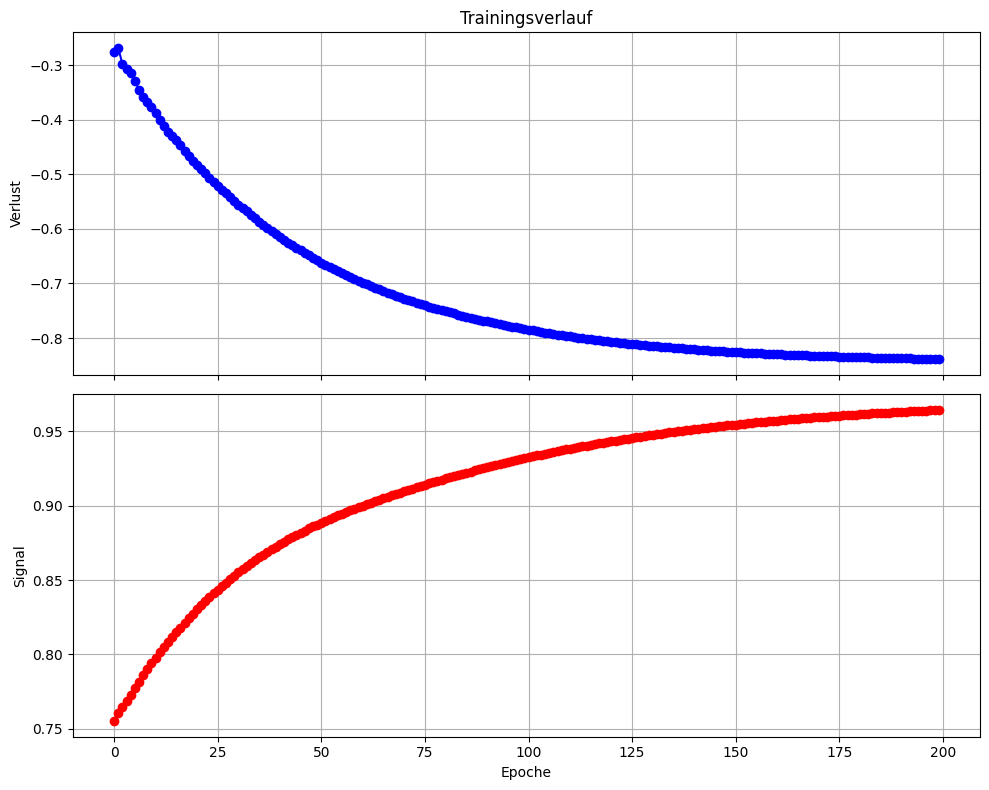

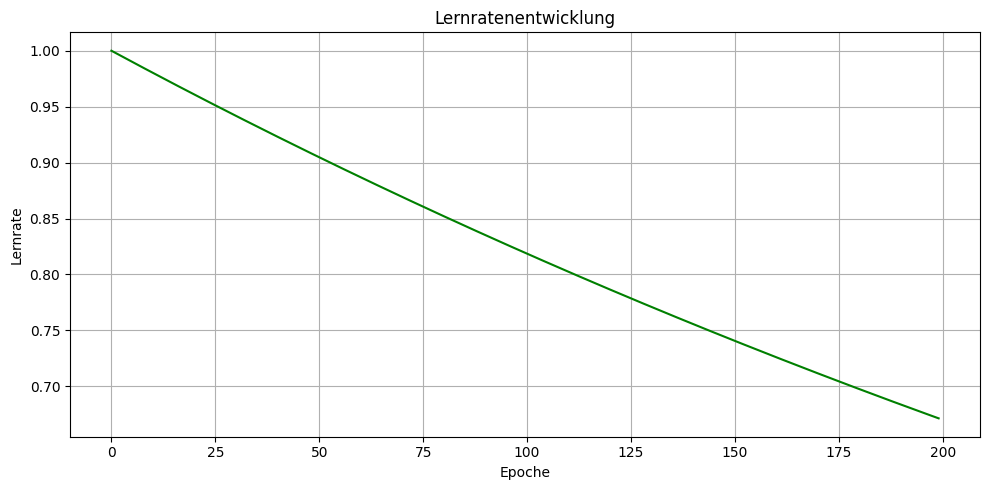

In [6]:
def initialize_custom_rf_pulse(original_rf_parameters, init_method='random', scaling_factor=0.5):
    """
    Initialisiert einen RF-Puls mit verschiedenen Methoden, um dem Optimierer mehr Freiheit zu geben.
    
    Args:
        original_rf_parameters: Die ursprünglichen RF-Parameter als Liste von [amp, phase] Paaren
        init_method: Methode zur Initialisierung ('random', 'flat', 'sine', 'mixed', 'original')
        scaling_factor: Skalierungsfaktor für die Amplitude (für 'random', 'sine', 'mixed')
        
    Returns:
        Neue RF-Parameter mit initialisierter Pulsform
    """
    custom_rf_parameters = []
    
    for i, [amp, phase] in enumerate(original_rf_parameters):
        # Behalte die ursprüngliche Phase bei
        new_phase = phase.clone().detach()
        
        # Hole die Dimensionen des originalen Pulses
        pulse_length = len(amp)
        max_amp_value = torch.max(amp).item()
        
        # Initialisierung je nach gewählter Methode
        if init_method == 'random':
            # Zufällige Initialisierung (gleichmäßig verteilt)
            new_amp = torch.rand_like(amp) * max_amp_value * scaling_factor
            
        elif init_method == 'flat':
            # Flache Initialisierung (konstante Amplitude)
            mean_amp = torch.mean(amp).item()
            new_amp = torch.ones_like(amp) * mean_amp
            
        elif init_method == 'sine':
            # Sinus-Initialisierung (eine andere Form als Gauß)
            x = torch.linspace(0, 2*torch.pi, pulse_length, device=amp.device, dtype=amp.dtype)
            new_amp = torch.sin(x) * max_amp_value * scaling_factor
            # Stelle sicher, dass die Werte positiv sind
            new_amp = torch.abs(new_amp)
            
        elif init_method == 'mixed':
            # Mischung aus Original und Zufälligkeit
            random_component = torch.rand_like(amp) * max_amp_value * scaling_factor
            # Das Original detachen, um den Berechnungsgraph zu trennen
            original_component = amp.clone().detach() * (1 - scaling_factor)
            new_amp = random_component + original_component
            
        else:  # 'original' oder andere Werte
            # Behalte die ursprüngliche Form bei
            new_amp = amp.clone().detach()
        
        # WICHTIG: Stellen Sie sicher, dass wir ein Blatt-Tensor haben (detach)
        # und eine neue Kopie erstellen (clone)
        new_amp = new_amp.detach().clone()
        # Dann erst kann requires_grad aktiviert werden
        new_amp.requires_grad_(True)
        
        # Füge das neue Paar zur Liste hinzu
        custom_rf_parameters.append([new_amp, new_phase])
    
    return custom_rf_parameters

def train(rf_parameters, diff_sim, num_epochs=50, learning_rate=0.1, 
          edge_penalty_weight=0.0001, smoothness_weight=0.0001, 
          checkpoint_dir='checkpoints/gauss_50seq', checkpoint_frequency=5,
          init_method='original', custom_init_scaling=0.5, lr_decay=0.995,
          momentum=0.9, use_scheduler=True, use_adam=True):
    """
    Führt das Training für die RF-Puls-Optimierung durch mit erweiterten Optionen.
    
    Args:
        rf_parameters: Liste von [amp, phase] Paaren
        diff_sim: Simulationsinstanz (SingleSimBMCWrapper)
        num_epochs: Anzahl der Trainingsepochen
        learning_rate: Lernrate für den Optimierer
        edge_penalty_weight: Gewichtung der Strafe für Nicht-Null-Enden des Pulses
        smoothness_weight: Gewichtung der Strafe für glatte Übergänge
        checkpoint_dir: Verzeichnis für Checkpoints
        checkpoint_frequency: Nach wievielen Epochen ein Checkpoint gespeichert wird
        init_method: Methode zur Initialisierung des RF-Pulses
        custom_init_scaling: Skalierungsfaktor für die benutzerdefinierte Initialisierung
        lr_decay: Faktor für die Lernratenabnahme bei Verwendung eines Schedulers
        momentum: Momentum für SGD-Optimierer (falls use_adam=False)
        use_scheduler: Ob ein Lernraten-Scheduler verwendet werden soll
        use_adam: Ob Adam statt SGD verwendet werden soll
    """
    # Initialisiere RF-Parameter mit der gewählten Methode, falls nicht 'original'
    if init_method != 'original':
        rf_parameters = initialize_custom_rf_pulse(rf_parameters, init_method, custom_init_scaling)
        print(f"RF-Puls mit Methode '{init_method}' neu initialisiert, Skalierungsfaktor: {custom_init_scaling}")
    
    # Extrahiere optimierbare Parameter aus der Liste von [amp, phase] Paaren
    optimizable_params = []
    
    for i, [amp, phase] in enumerate(rf_parameters):
        # Sicherstellen, dass amp ein Blatt-Tensor ist
        optimizable_params.append(amp)
    
    # Checkpoint-Verzeichnis erstellen
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    # Initialisiere den Optimierer
    if use_adam:
        optimizer = torch.optim.Adam(optimizable_params, lr=learning_rate)
    else:
        optimizer = torch.optim.SGD(optimizable_params, lr=learning_rate, momentum=momentum)
    
    # Optional: Lernraten-Scheduler
    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
    
    # Variablen für Tracking
    best_signal = float('-inf')
    best_parameters = None
    epochs_list = []
    losses_list = []
    signals_list = []
    learning_rates = []
    
    # Trainingsschleife
    for epoch in range(num_epochs):
        # Führe die Simulation mit aktuellen Parametern durch
        signal = diff_sim(rf_parameters)
        
        # Berechne den Verlust mit der angepassten Verlustfunktion
        loss = signal_objective_function(signal, rf_parameters, edge_penalty_weight, smoothness_weight)
        
        # Führe Backpropagation durch
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Signal (negierter Verlust ohne Strafe) für die Ausgabe
        pure_signal_value = torch.abs(signal).item()
        
        # Tracking
        epochs_list.append(epoch)
        losses_list.append(loss.item())
        signals_list.append(pure_signal_value)
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)
        
        # Ausgabe
        print(f"Epoche {epoch}/{num_epochs - 1} - Signal: {pure_signal_value:.6f}, Verlust: {loss.item():.6f}, LR: {current_lr:.6f}")
        
        # Speichere den besten Zustand (basierend auf dem reinen Signal)
        if pure_signal_value > best_signal:
            best_signal = pure_signal_value
            # Klonen der aktuellen Parameter
            best_parameters = []
            for amp, phase in rf_parameters:
                best_parameters.append([amp.detach().clone(), phase.detach().clone()])
            
            save_checkpoint(
                checkpoint_dir, 
                best_parameters, 
                optimizer, 
                epoch, 
                loss.item(), 
                pure_signal_value,
                checkpoint_name="best_checkpoint.pt"
            )
            print(f"  Neuer Bestwert gefunden und gespeichert!")
        
        # Speichere regelmäßige Checkpoints
        if epoch % checkpoint_frequency == 0 or epoch == num_epochs - 1:
            current_parameters = []
            for amp, phase in rf_parameters:
                current_parameters.append([amp.detach().clone(), phase.detach().clone()])
                
            save_checkpoint(
                checkpoint_dir, 
                current_parameters, 
                optimizer, 
                epoch, 
                loss.item(), 
                pure_signal_value
            )
            
        # Update des Schedulers, falls verwendet
        if scheduler and epoch < num_epochs - 1:  # Nicht im letzten Epoch aktualisieren
            scheduler.step()
    
    # Speichere den finalen Zustand
    final_parameters = []
    for amp, phase in rf_parameters:
        final_parameters.append([amp.detach().clone(), phase.detach().clone()])
        
    final_path = save_checkpoint(
        checkpoint_dir, 
        final_parameters, 
        optimizer, 
        num_epochs - 1, 
        losses_list[-1], 
        signals_list[-1],
        checkpoint_name="final_checkpoint.pt"
    )
    
    # Plotte den Fortschritt
    fig = plot_progress(
        epochs_list, 
        losses_list, 
        signals_list,
        save_path=os.path.join(checkpoint_dir, "training_progress.png")
    )
    
    # Zusätzlichen Plot für die Lernraten erstellen
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_list, learning_rates, 'g-')
    plt.title('Lernratenentwicklung')
    plt.xlabel('Epoche')
    plt.ylabel('Lernrate')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(checkpoint_dir, "learning_rate_progress.png"))
    
    print("\nTraining abgeschlossen!")
    print(f"Bestes Signal: {best_signal:.6f}")
    
    return best_parameters, best_signal, final_path, fig

# Training ausführen mit den neuen freieren Parametern
# Versuchen wir jetzt mit einer völlig anderen Initialisierung
best_parameters, best_signal, final_checkpoint_path, progress_plot = train(
    rf_parameters, diff_sim, 
    num_epochs=200,
    learning_rate=1.0,
    edge_penalty_weight=0.001,
    smoothness_weight=0.0002,
    init_method='original',  # Starte mit einer Sinus-Form statt einer Mischung
    custom_init_scaling=1.0,  # Volle Amplitude für maximale Änderung
    lr_decay=0.998,
    use_scheduler=True,
    use_adam=True,
    checkpoint_frequency=10
)

## Visualisierung der Ergebnisse

Nach Abschluss des Trainings können wir die optimierten Parameter laden und visualisieren.

Original-Signal: 0.755150
Optimiertes Signal: 0.964372
Verbesserung: 27.71%


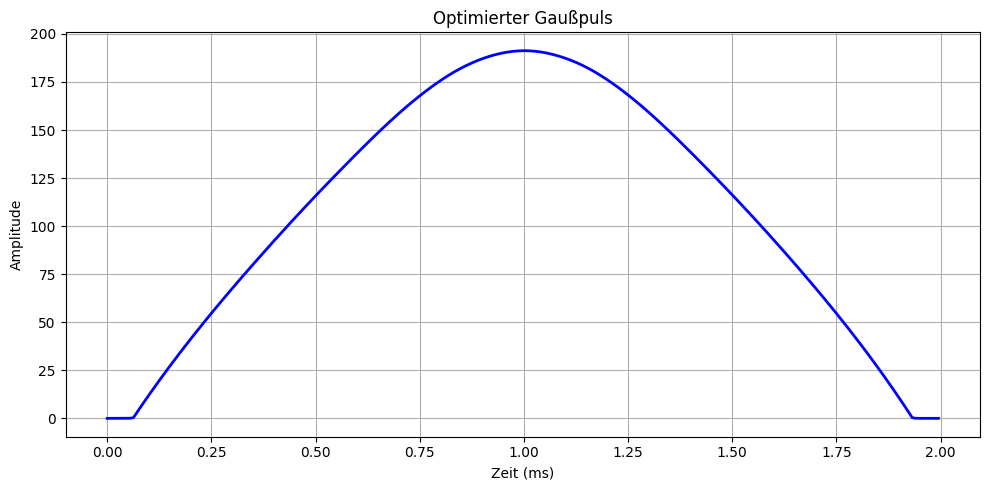

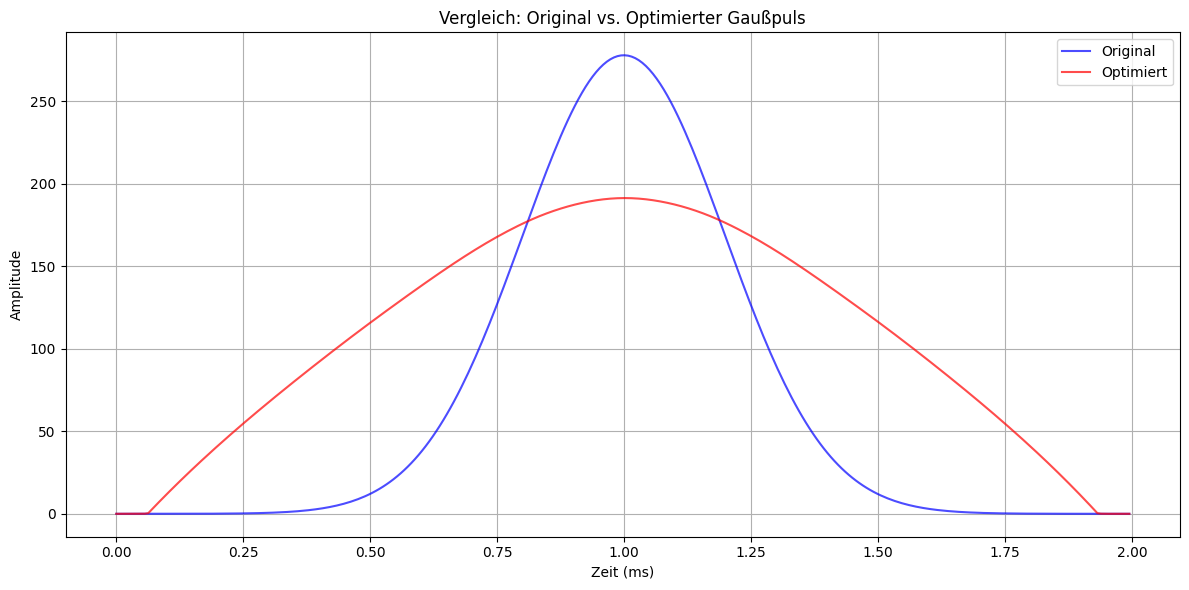

In [7]:
# Prüfen, ob optimierte Parameter vorhanden sind (nach dem Training)
if 'best_parameters' in locals():
    # Visualisieren des optimierten Pulses
    visualize_pulse(best_parameters, dtp_rf, f"Optimierter Gaußpuls")
    
    # Vergleich mit Original
    with torch.no_grad():
        original_signal = diff_sim(original_pulse_parameters)
        optimized_signal = diff_sim(best_parameters)
        
    print(f"Original-Signal: {original_signal.item():.6f}")
    print(f"Optimiertes Signal: {optimized_signal.item():.6f}")
    
    if abs(original_signal.item()) > 0:
        improvement = (optimized_signal.item() - original_signal.item()) / abs(original_signal.item()) * 100
        print(f"Verbesserung: {improvement:.2f}%")
    
    # Vergleichsplot der Pulsformen
    plt.figure(figsize=(12, 6))
    
    # Original-Puls
    pulse_orig = original_pulse_parameters[0][0].detach().cpu().numpy()  # Extrahiere Amplituden des ersten Pulses
    time_axis = np.arange(len(pulse_orig)) * dtp_rf * 1000  # Umrechnung in ms
    plt.plot(time_axis, pulse_orig, 'b-', linewidth=1.5, alpha=0.7, label='Original')
    
    # Optimierter Puls
    pulse_opt = best_parameters[0][0].detach().cpu().numpy()  # Extrahiere Amplituden des ersten Pulses
    plt.plot(time_axis, pulse_opt, 'r-', linewidth=1.5, alpha=0.7, label='Optimiert')
    
    plt.title("Vergleich: Original vs. Optimierter Gaußpuls")
    plt.xlabel('Zeit (ms)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
else:
    print("Keine optimierten Parameter gefunden. Bitte führe zuerst das Training aus.")

ValueError: x and y must have same first dimension, but have shapes (301,) and (302,)

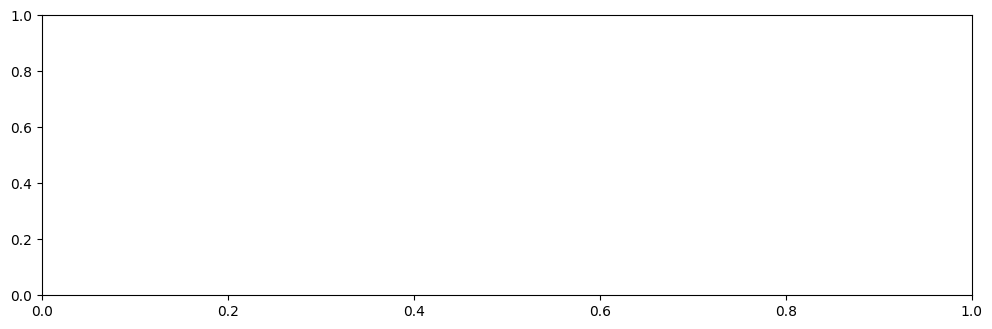

In [8]:
# Diese Funktion ermöglicht es uns, die Magnetisierungskomponenten zu extrahieren und zu plotten
# Ausführen, wenn das Training abgeschlossen ist und ein optimierter Puls vorhanden ist

if 'best_parameters' in locals():
    from bmc.utils.eval import plot_sim
    
    # Funktion zum Extrahieren der Magnetisierungskomponenten
    def get_magnetization_components(params, diff_sim):
        """Extrahiert die Magnetisierungskomponenten aus einer Simulation"""
        with torch.no_grad():
            # Signal berechnen (wird nicht verwendet, aber initiiert die Simulation)
            _ = diff_sim(params)
            # Magnetisierungskomponenten extrahieren
            time, m_z, m_z_total, m_c, m_c_total = diff_sim.sim_engine.get_mag(return_cest_pool=False)
            
            # CPU NumPy Arrays erstellen
            time = time.cpu().numpy()
            m_z = m_z.cpu().numpy()
            m_z_total = m_z_total.cpu().numpy()
            m_c = m_c.cpu().numpy()
            m_c_total = m_c_total.cpu().numpy()
            
            return time, m_z, m_z_total, m_c, m_c_total
    
    # Magnetisierungskomponenten für originalen und optimierten Puls extrahieren
    time_orig, m_z_orig, m_z_total_orig, m_c_orig, m_c_total_orig = get_magnetization_components(original_pulse_parameters, diff_sim)
    time_opt, m_z_opt, m_z_total_opt, m_c_opt, m_c_total_opt = get_magnetization_components(best_parameters, diff_sim)
    
    # Zentrale Isochromat wählen (Position 0)
    iso_select = [0]
    
    # Plot der z-Magnetisierung (longitudinal)
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(time_orig, m_z_total_orig, 'b-', label="Original")
    plt.plot(time_opt, m_z_total_opt, 'r-', label="Optimiert")
    plt.title("Zeitverlauf der z-Magnetisierung")
    plt.xlabel("Zeit (s)")
    plt.ylabel("Mz")
    plt.grid(True)
    plt.legend()
    
    # Plot der transversalen Magnetisierung
    plt.subplot(2, 1, 2)
    plt.plot(time_orig, np.abs(m_c_total_orig), 'b-', label="Original")
    plt.plot(time_opt, np.abs(m_c_total_opt), 'r-', label="Optimiert")
    plt.title("Zeitverlauf der transversalen Magnetisierung")
    plt.xlabel("Zeit (s)")
    plt.ylabel("|Mxy|")
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    
    # ADC-Bereich detailliert betrachten (letzter Teil der Simulation)
    plt.figure(figsize=(10, 5))
    adc_start_idx = int(0.9 * len(time_orig))  # Ungefähr die letzten 10% der Simulationszeit
    
    plt.plot(time_orig[adc_start_idx:], np.abs(m_c_total_orig[adc_start_idx:]), 'b-', linewidth=2, label="Original")
    plt.plot(time_opt[adc_start_idx:], np.abs(m_c_total_opt[adc_start_idx:]), 'r-', linewidth=2, label="Optimiert")
    
    plt.title("Detailansicht der transversalen Magnetisierung im ADC-Bereich")
    plt.xlabel("Zeit (s)")
    plt.ylabel("|Mxy|")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
else:
    print("Keine optimierten Parameter gefunden. Bitte führe zuerst das Training aus.")